# Satellite Observations

In [1]:
%load_ext autoreload
%autoreload 2
    
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
from prithvi_precip.datasets import DirectPrecipForecastWithObsDataset

ds = DirectPrecipForecastWithObsDataset(
    "/data1/prithvi_precip/data/test_data/",
    reference_data="mrms",
    source="geos",
    #local_data="/data1/prithvi_precip/local",
)

[23:40:27] WARNING  No 'geos' input files found in /data1/prithvi_precip/data/test_data. Note that the ]8;id=8351;file:///home/simon/src/prithvi_precip/src/prithvi_precip/utils.py\utils.py]8;;\:]8;id=765051;file:///home/simon/src/prithvi_precip/src/prithvi_precip/utils.py#368\368]8;;\
                    search doesn't descend into sym-linked folders.                                                

In [ ]:
obs = ds.obs_loader.get_observation_mask(np.datetime64("2022-01-01"), np.datetime64("2023-01-01"))

  0%|                                                                                                     | 3/2921 [00:00<09:35,  5.07it/s]

[23:40:41] ERROR    Encountered an error when observation file                                  ]8;id=692524;file:///home/simon/src/prithvi_precip/src/prithvi_precip/datasets/observations.py\observations.py]8;;\:]8;id=604341;file:///home/simon/src/prithvi_precip/src/prithvi_precip/datasets/observations.py#300\300]8;;\
                    /data1/prithvi_precip/data/test_data/obs/2022/01/01/obs_20220101090000.nc.                     
                    ╭─────────────────── Traceback (most recent call last) ───────────────────╮                    
                    │ /home/simon/src/prithvi_precip/src/prithvi_precip/datasets/observations │                    
                    │ .py:288 in get_observation_mask                                         │                    
                    │                                                                         │                    
                    │   285 │   │   │   path = self.observation_path / date.strftime("%Y/%m/% │                    
                    │   286 │   │   │   if path.exists():                                     │                    
                    │   287 │   │   │   │   try:                                              │                    
                    │ ❱ 288 │   │   │   │   │   with xr.open_dataset(path) as obs_data:       │                    
                    │   289 │   │   │   │   │   │   obs_times.append(time)                    │                    
                    │   290 │   │   │   │   │   │   obs_tiles.append(np.zeros((obs_bins.size  │                    
                    │   291                                                                   │                    
                    │                                                                         │                    
                    │ /home/simon/miniforge3/envs/precipfm/lib/python3.11/site-packages/xarra │                    
                    │ y/backends/api.py:667 in open_dataset                                   │                    
                    │                                                                         │                    
                    │    664 │   │   kwargs.update(backend_kwargs)                            │                    
                    │    665 │                                                                │                    
                    │    666 │   if engine is None:                                           │                    
                    │ ❱  667 │   │   engine = plugins.guess_engine(filename_or_obj)           │                    
                    │    668 │                                                                │                    
                    │    669 │   if from_array_kwargs is None:                                │                    
                    │    670 │   │   from_array_kwargs = {}                                   │                    
                    │                                                                         │                    
                    │ /home/simon/miniforge3/envs/precipfm/lib/python3.11/site-packages/xarra │                    
                    │ y/backends/plugins.py:194 in guess_engine                               │                    
                    │                                                                         │                    
                    │   191 │   │   │   "https://docs.xarray.dev/en/stable/getting-started-gu │                    
                    │   192 │   │   )                                                         │                    
                    │   193 │                                                                 │                    
                    │ ❱ 194 │   raise ValueError(error_msg)                                   │                    
                    │   195                                                 

 49%|███████████████████████████████████████████████▌                                                  | 1419/2921 [05:05<05:20,  4.68it/s]

In [91]:
n_tiles = obs.mask.sum(("lat_tiles", "lon_tiles"))

In [94]:
from prithvi_precip.obs.gpm import SENSORS

# 

In [118]:
from h5py import File
hndl = File("/data3/satellite_data/gpm/1c/f17/ssmis/1C.F17.SSMIS.XCAL2021-V.20250704-S053725-E071914.096322.V07B.HDF5")

In [119]:
hndl["S1"]["Latitude"]

<HDF5 dataset "Latitude": shape (0, 90), type "<f4">

In [117]:
SENSORS["ssmis"][1][2][-1].get("2025-07-02")

[FileRecord(filename='1C.F17.SSMIS.XCAL2021-V.20250701-S231841-E010031.096290.V07B.HDF5', local_path=PosixPath('/data2/satellite_data/gpm/1c/f17/ssmis/1C.F17.SSMIS.XCAL2021-V.20250701-S231841-E010031.096290.V07B.HDF5'), product=<pansat.products.satellite.gpm.GPMProduct object at 0x723533e4f110>, provider=<pansat.download.providers.ges_disc.GesDiscProviderDay object at 0x7235277995d0>, remote_path='https://gpm1.gesdisc.eosdis.nasa.gov/data/GPM_L1C/GPM_1CF17SSMIS.07/2025/182/1C.F17.SSMIS.XCAL2021-V.20250701-S231841-E010031.096290.V07B.HDF5')]

/tmp/ipykernel_316079/1024518127.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


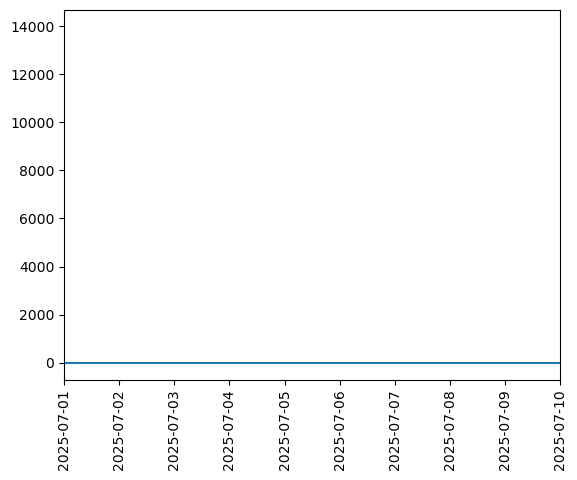

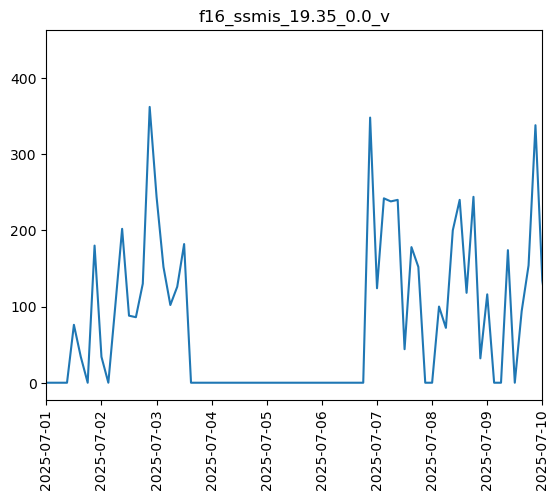

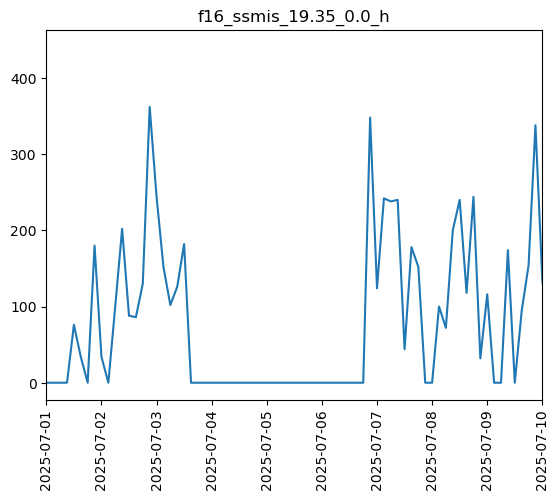

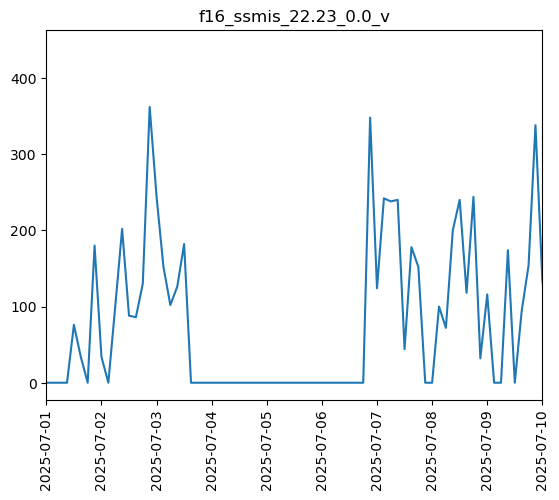

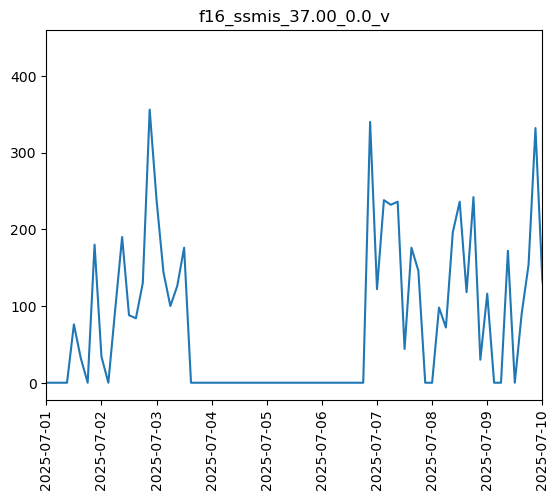

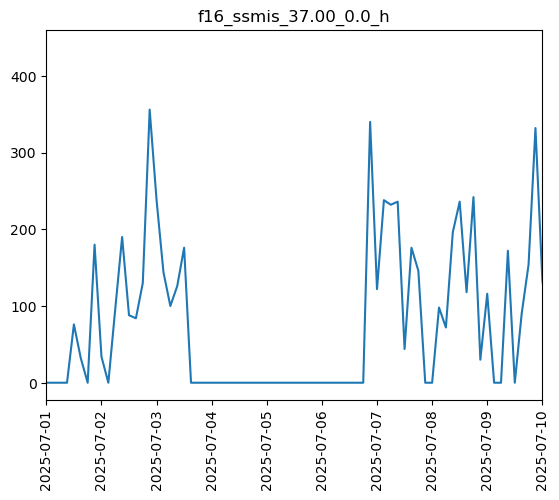

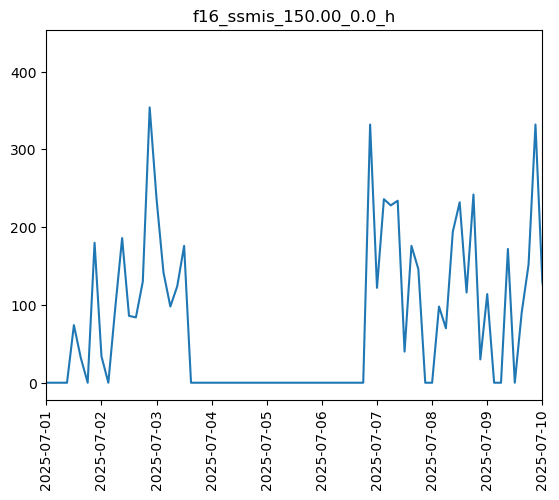

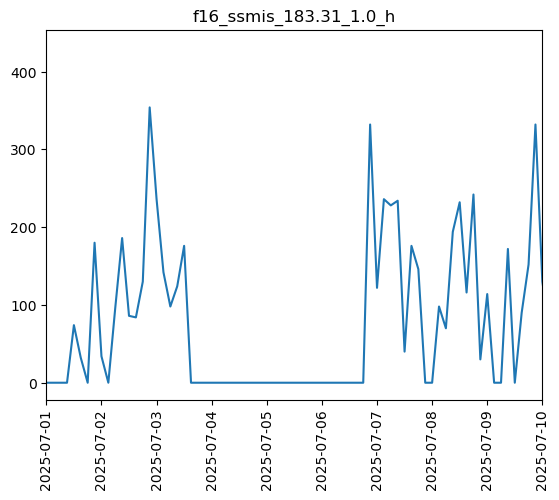

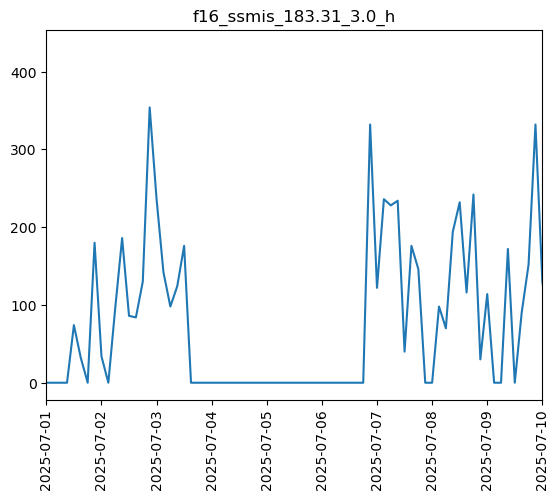

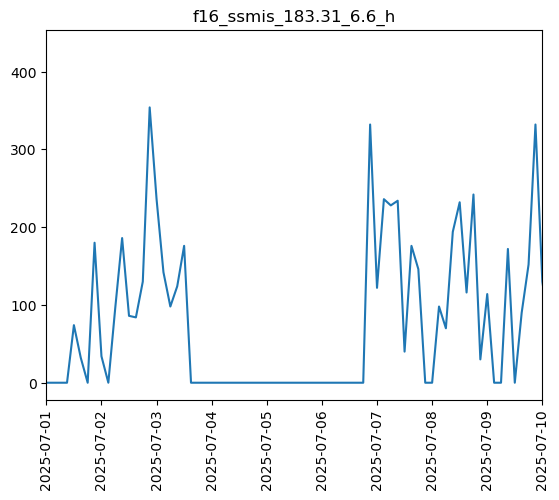

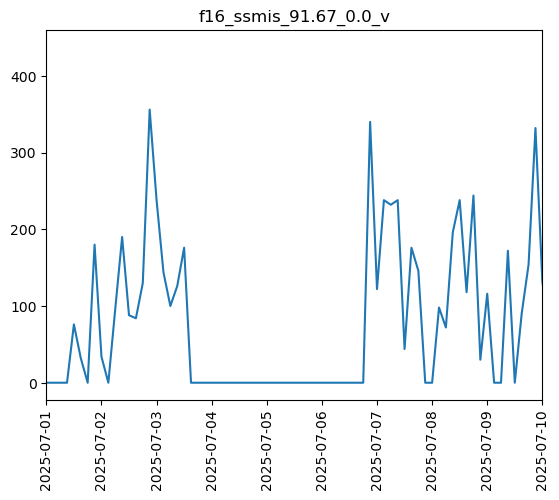

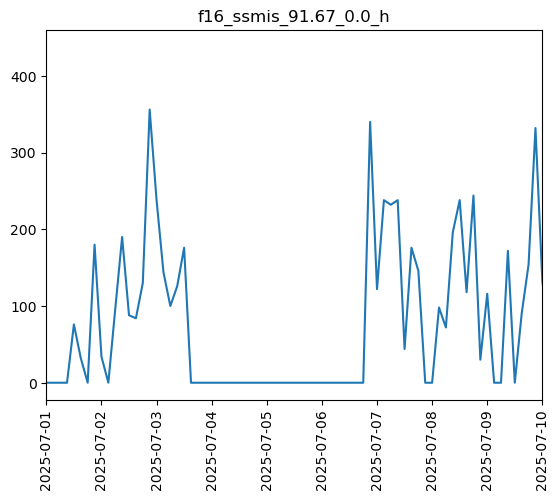

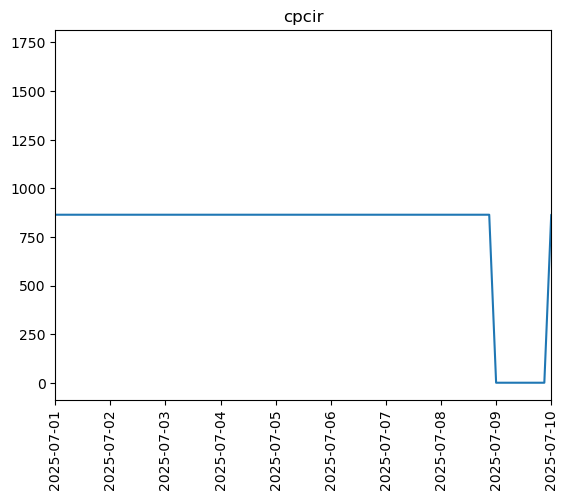

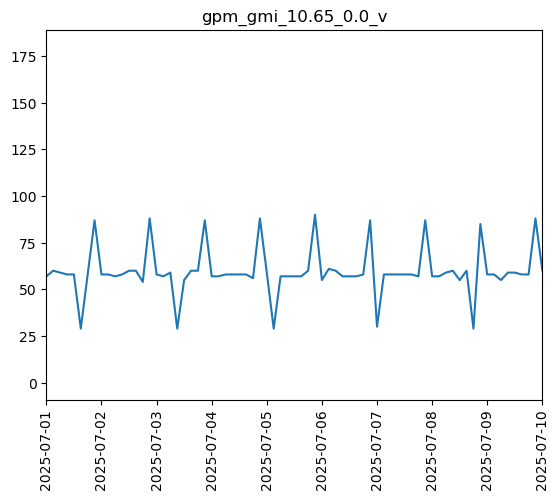

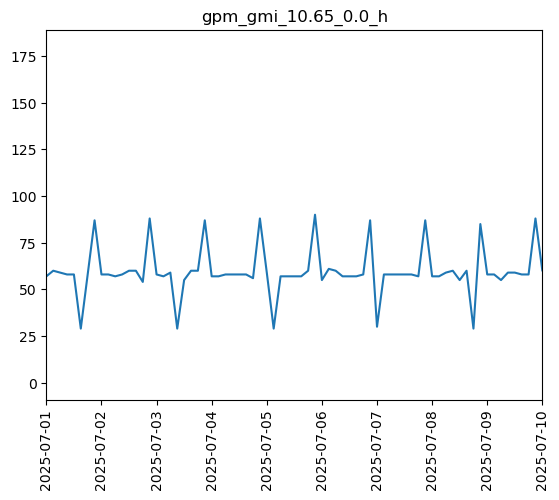

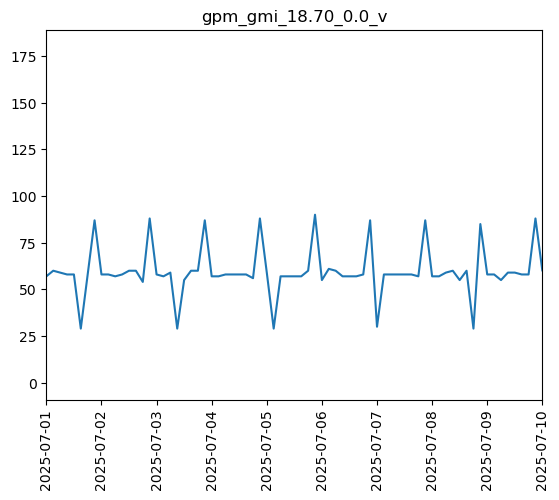

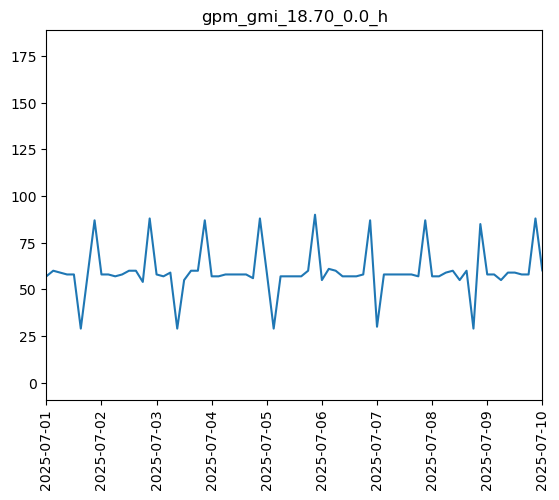

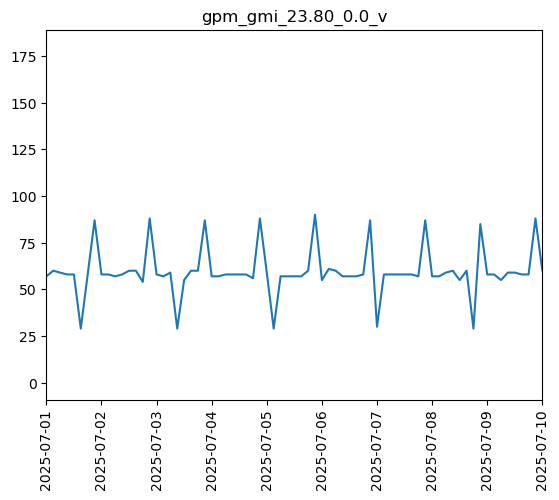

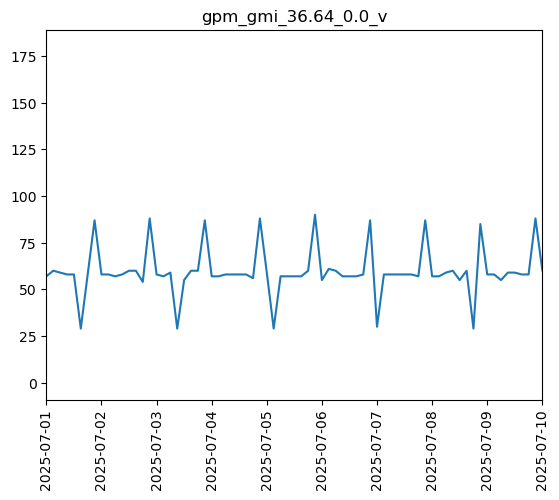

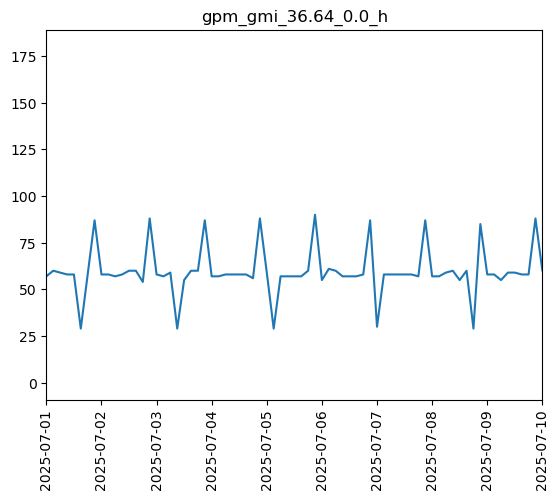

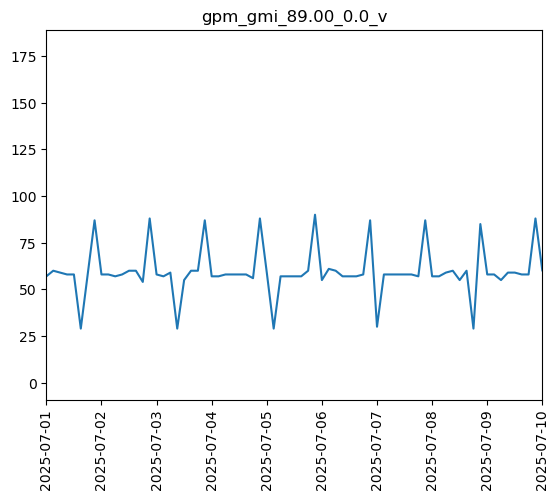

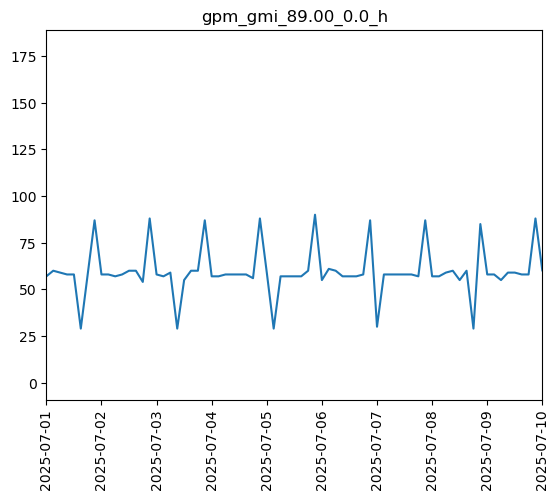

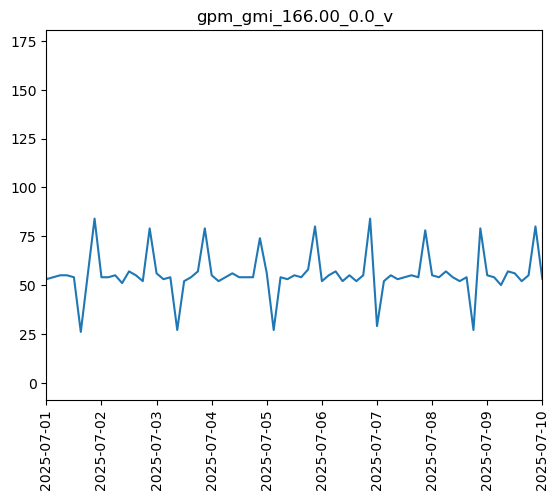

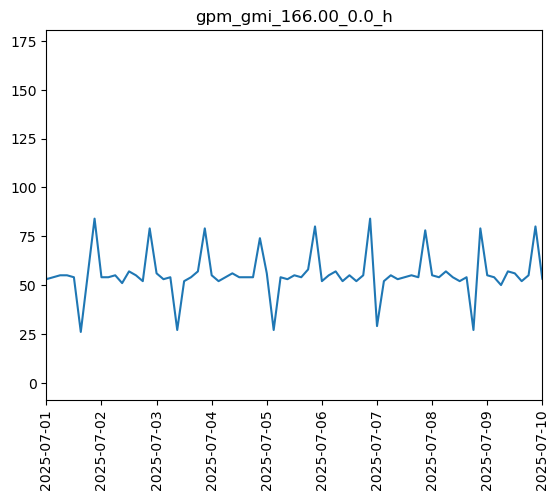

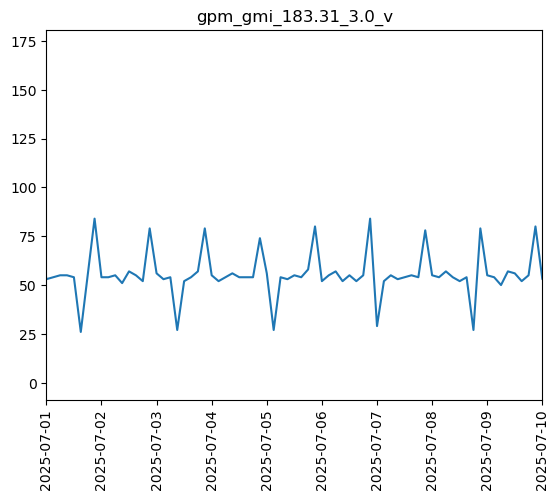

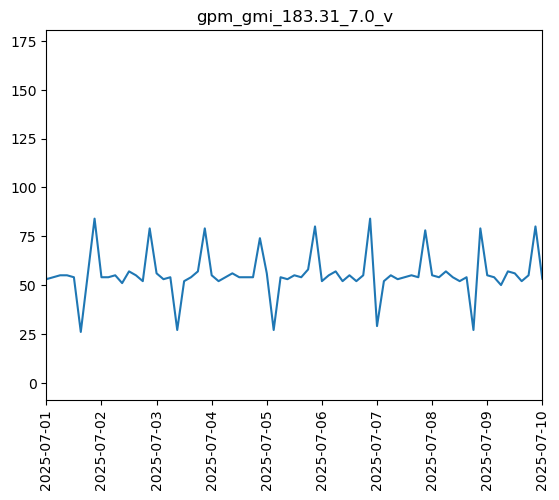

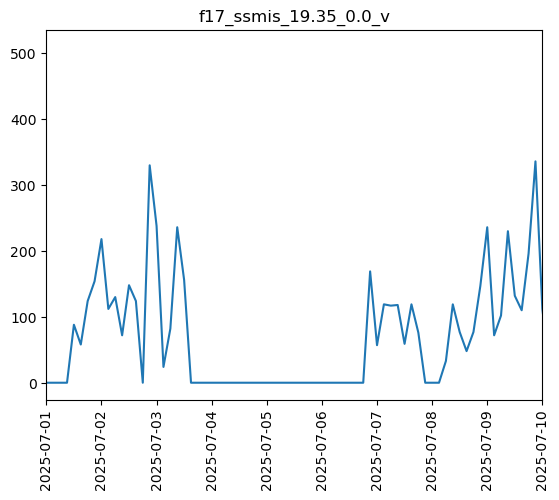

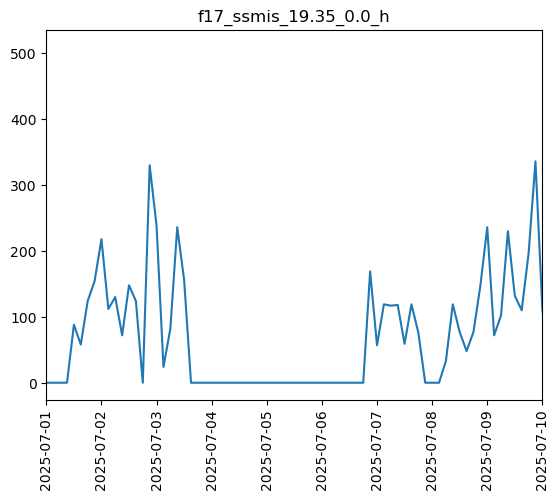

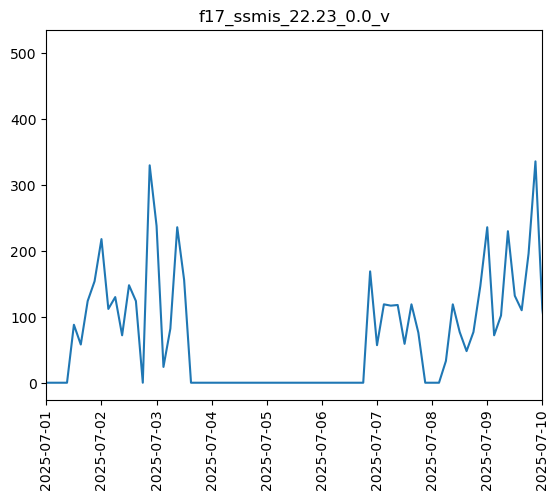

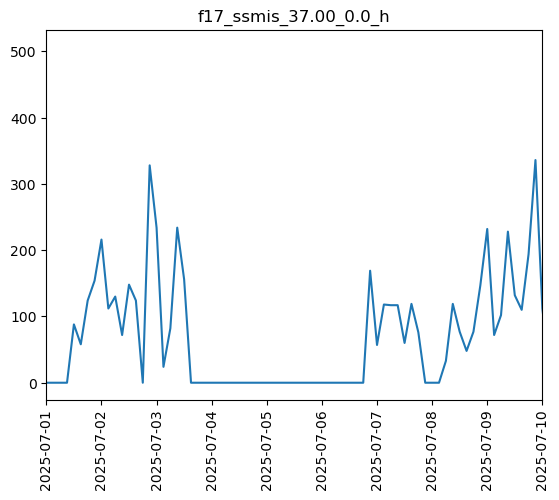

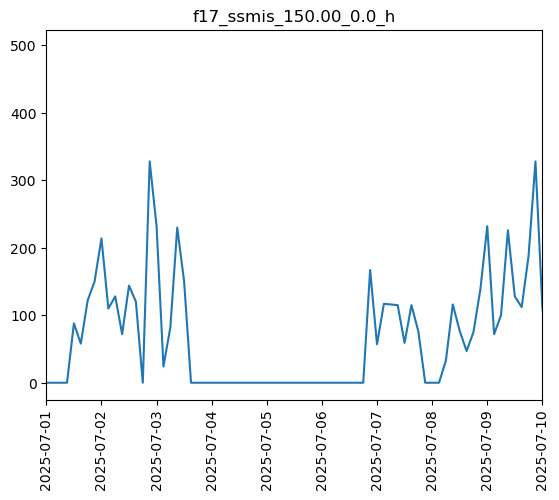

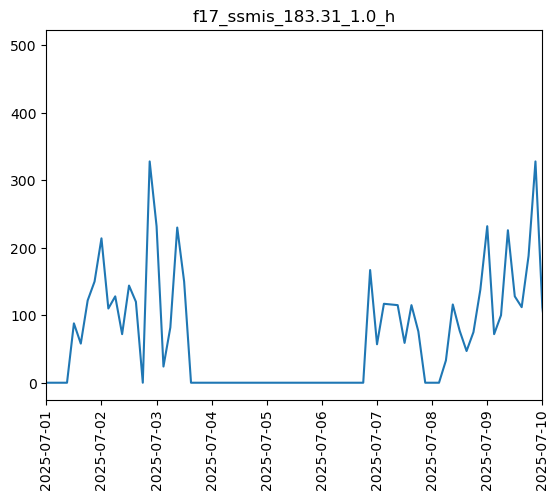

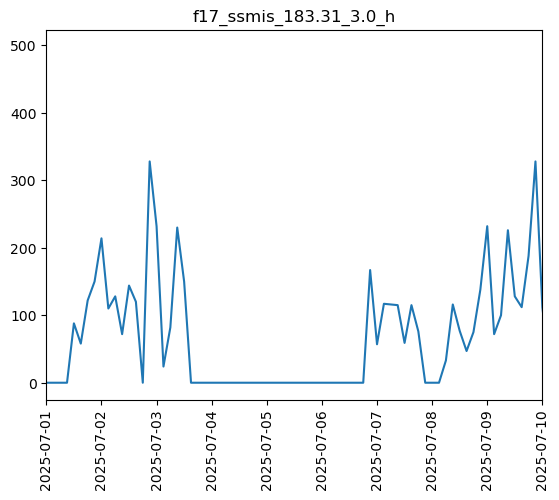

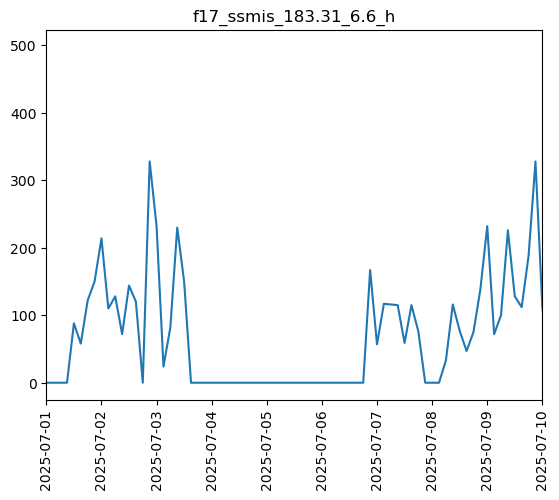

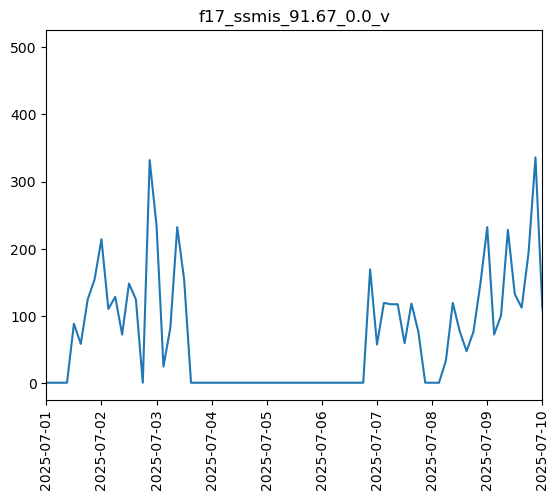

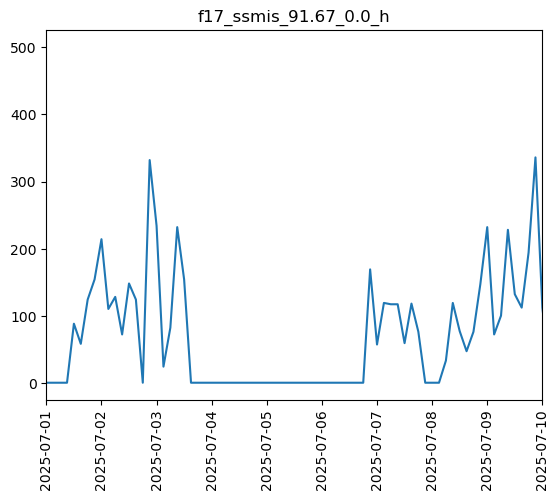

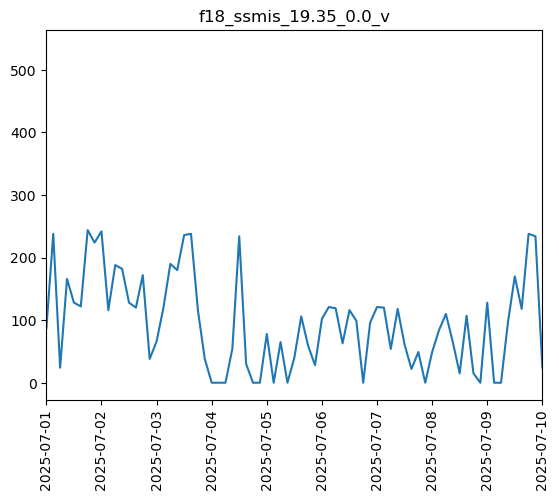

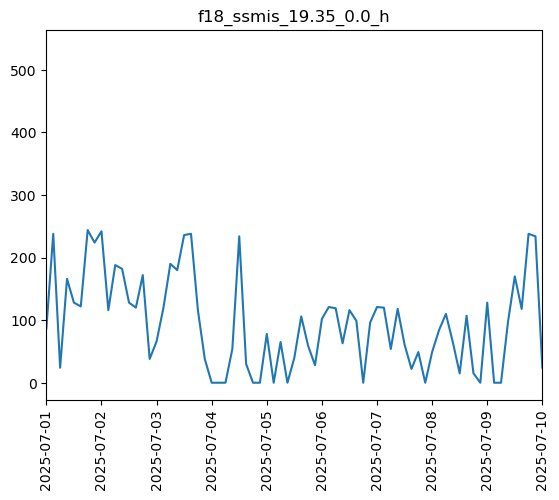

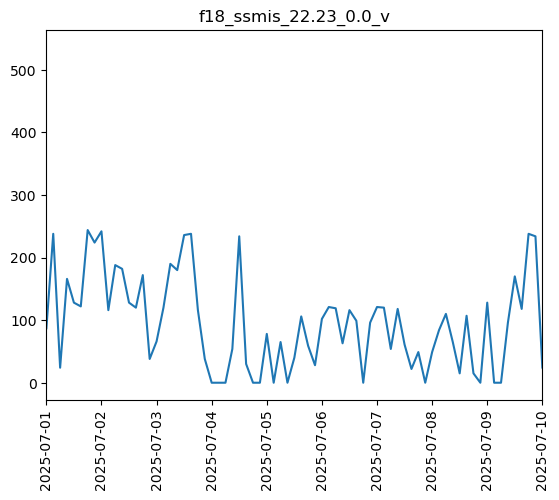

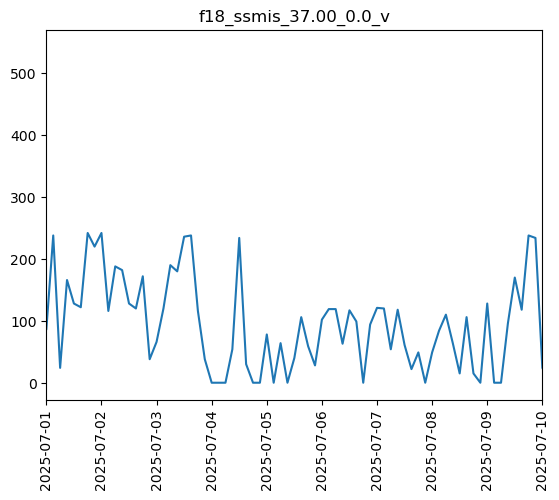

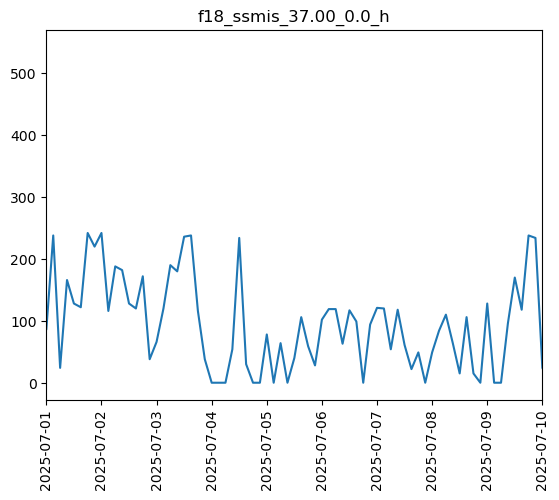

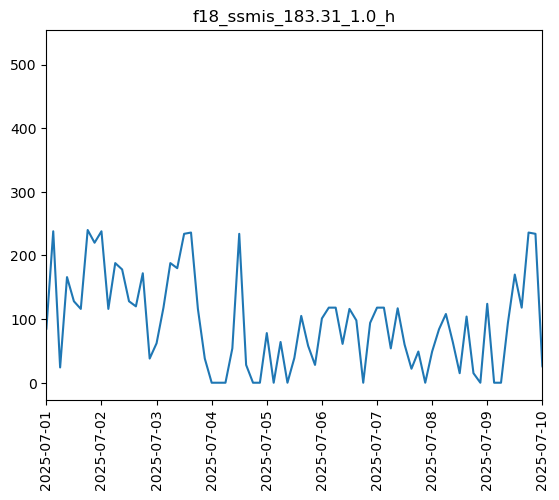

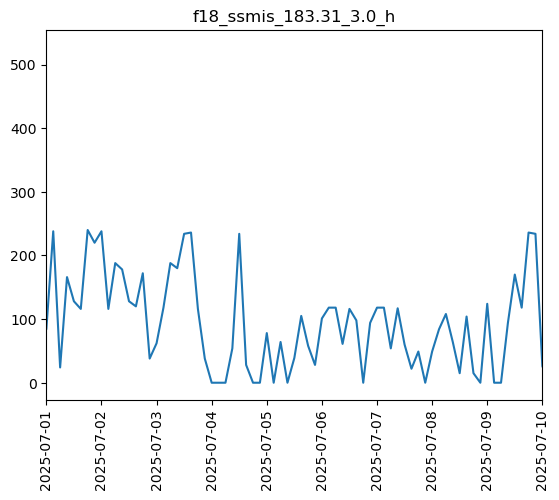

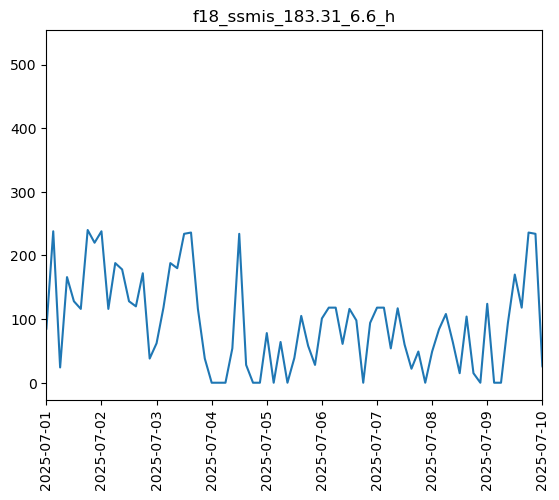

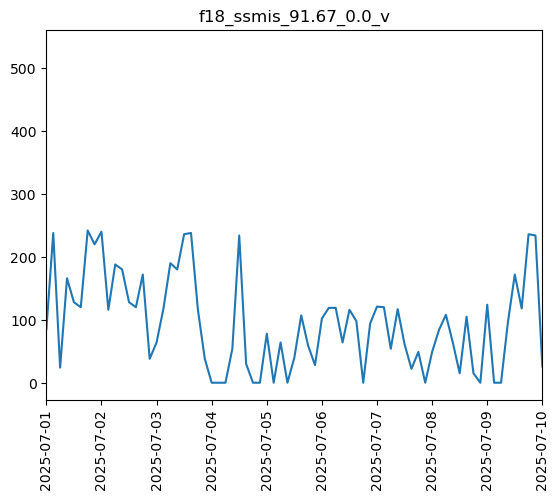

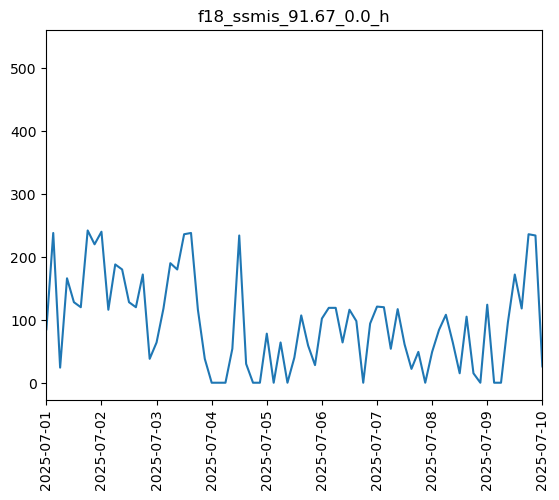

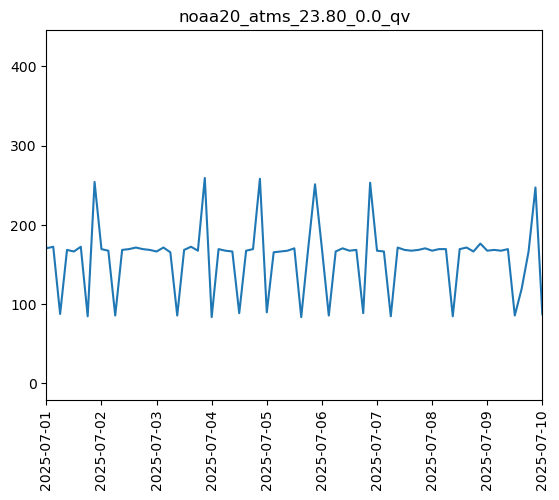

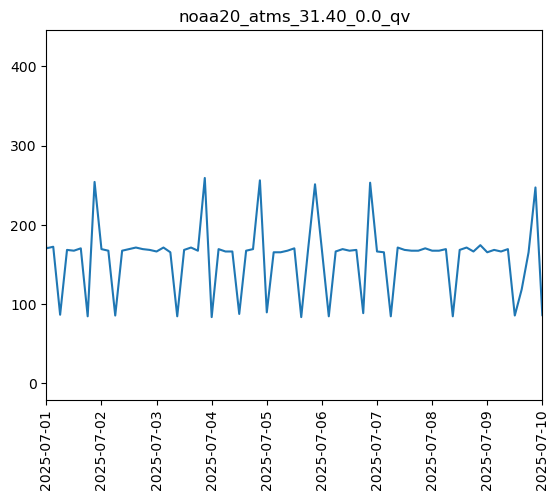

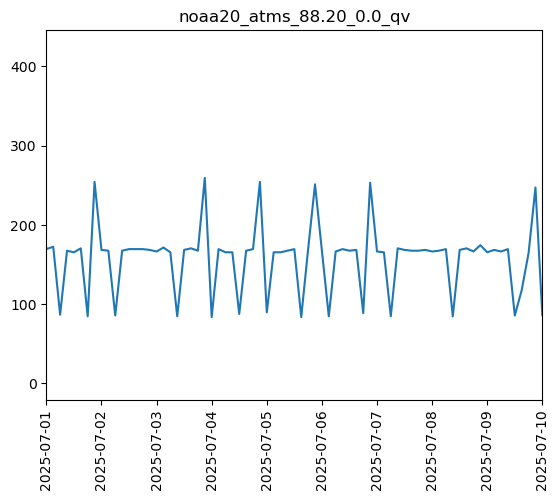

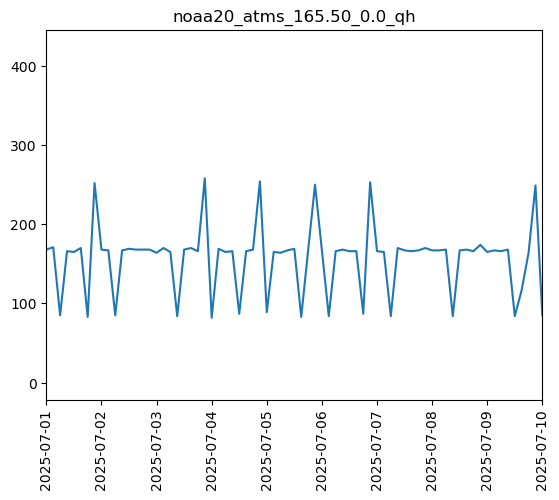

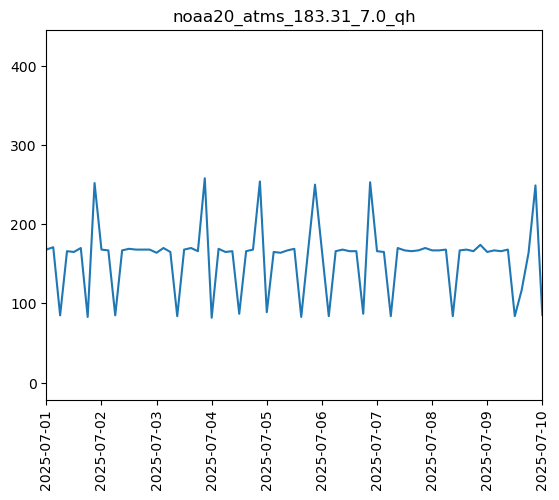

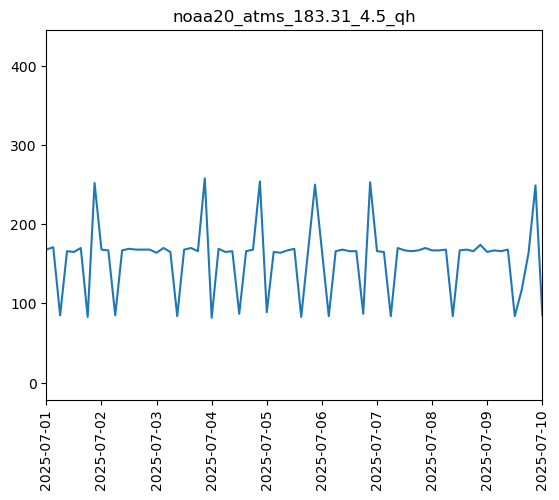

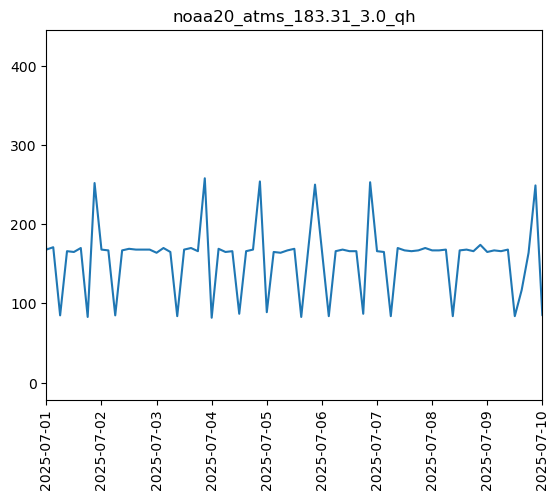

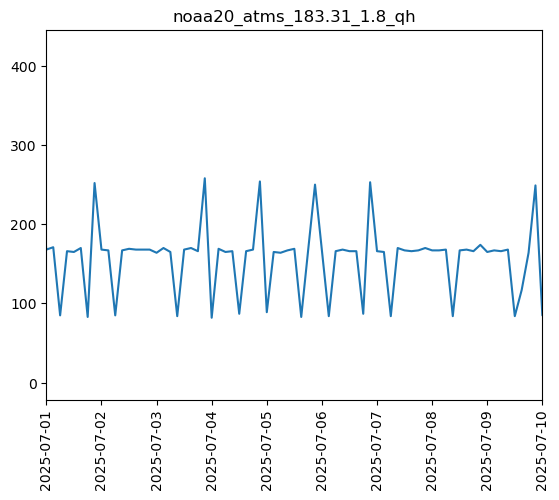

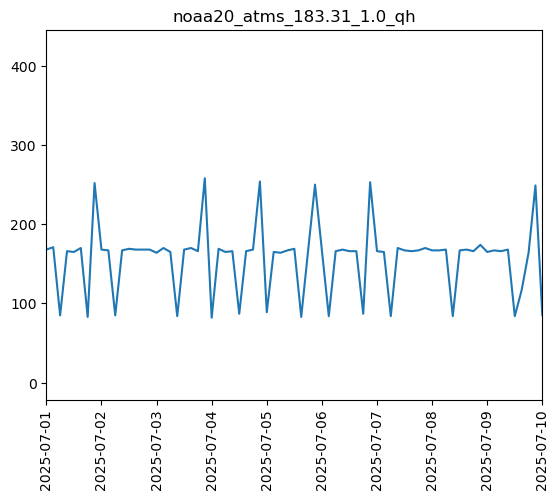

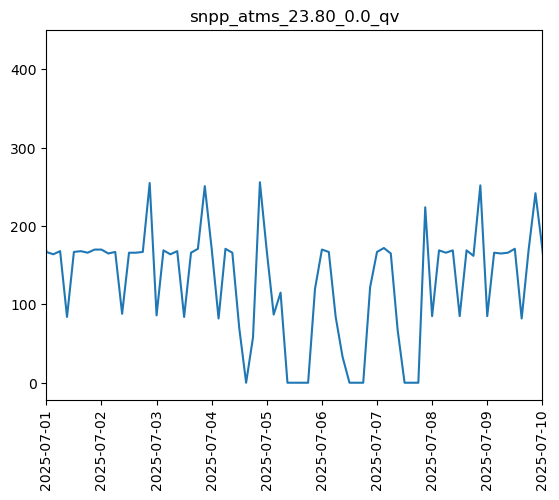

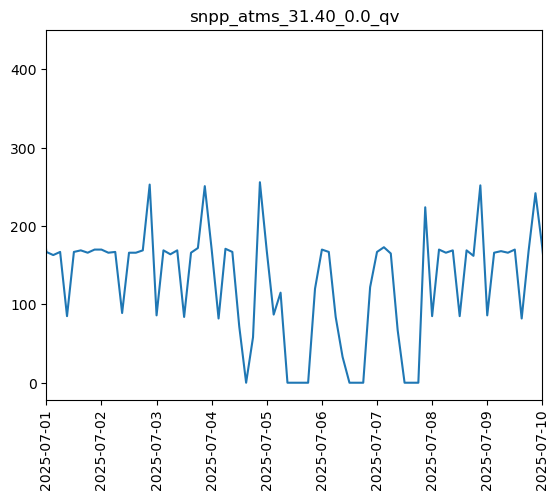

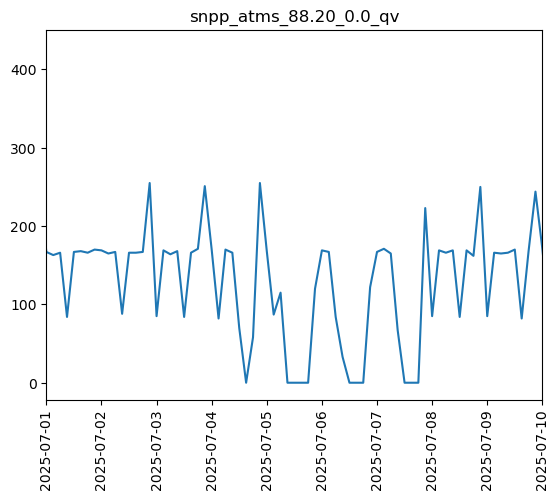

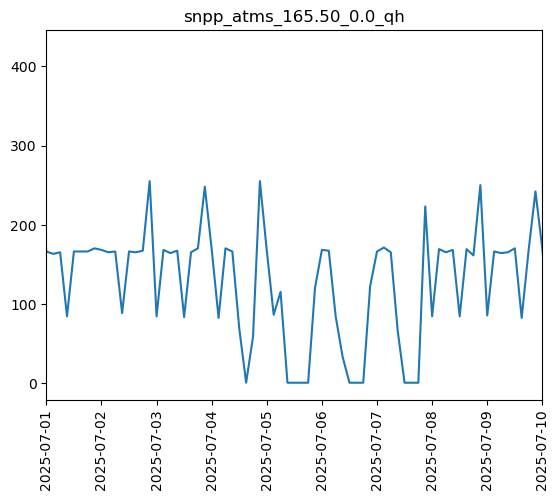

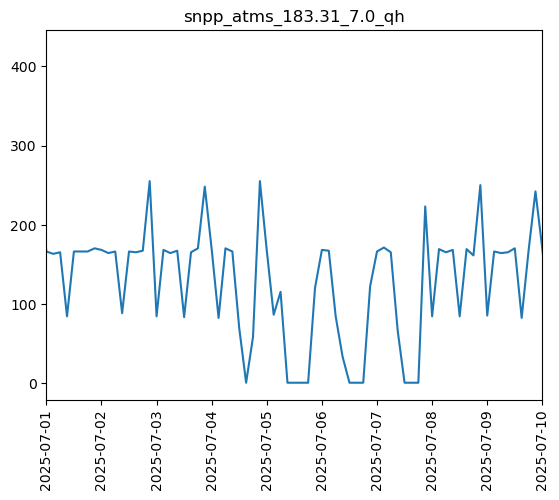

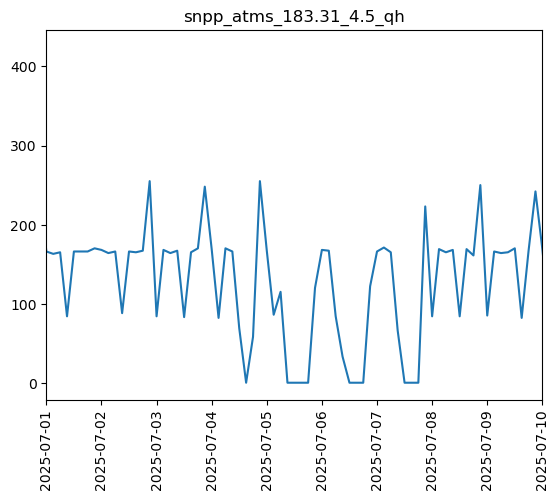

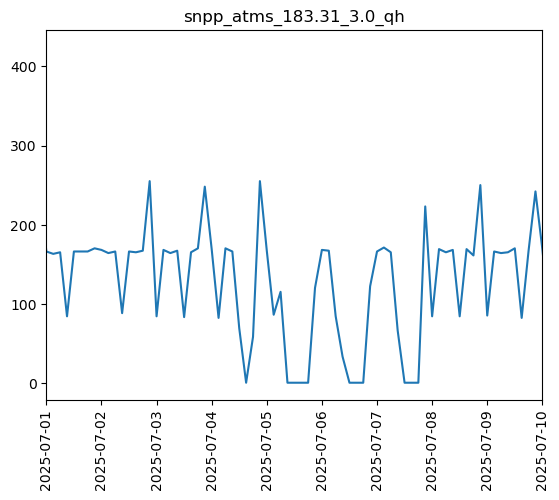

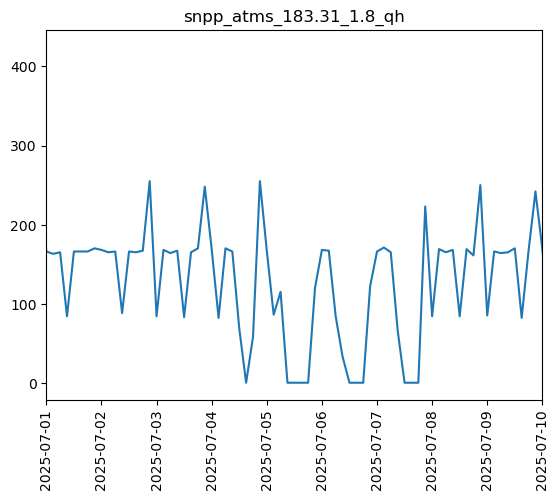

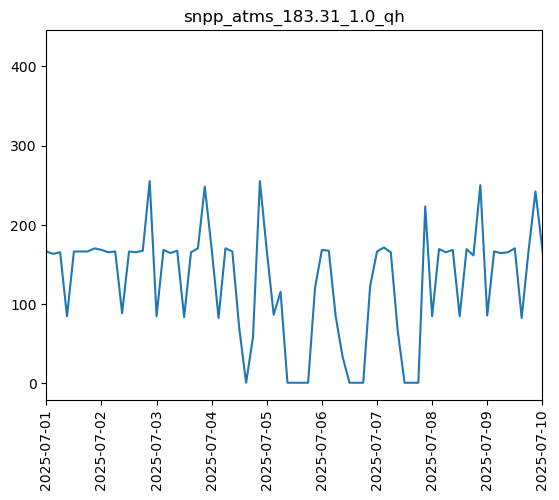

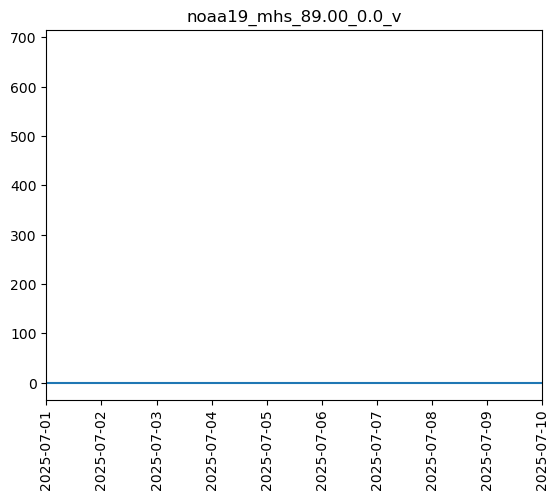

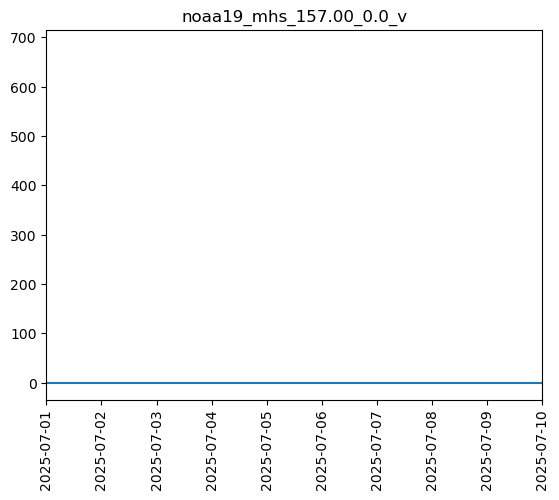

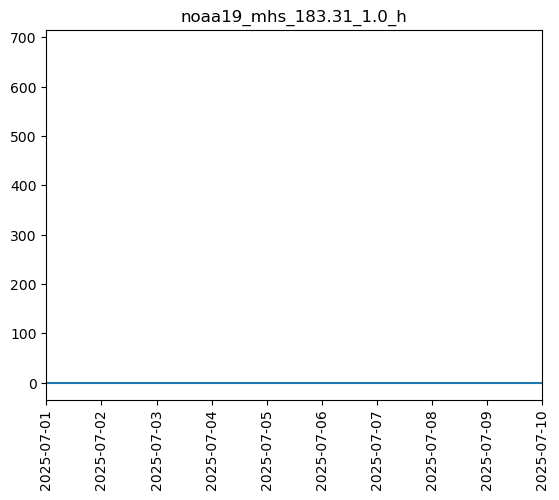

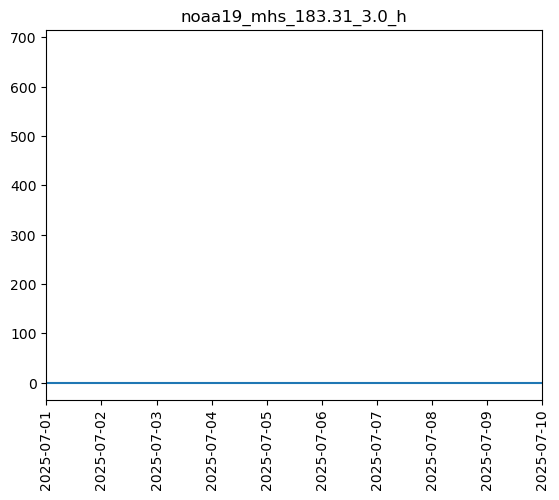

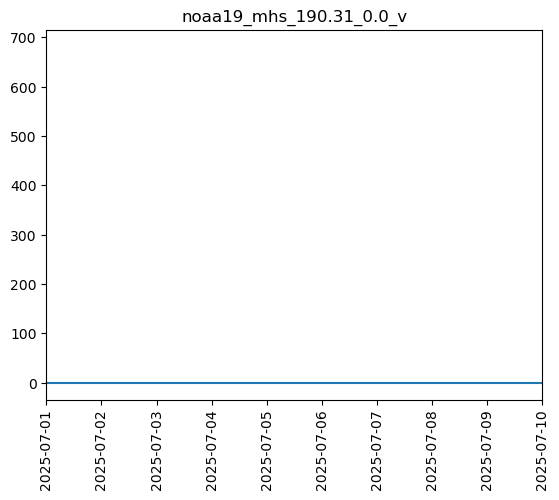

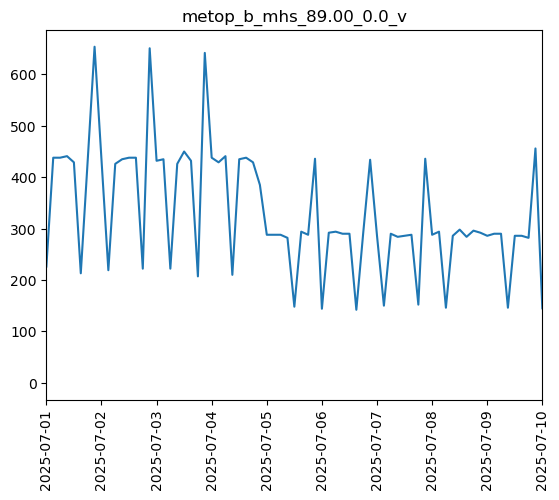

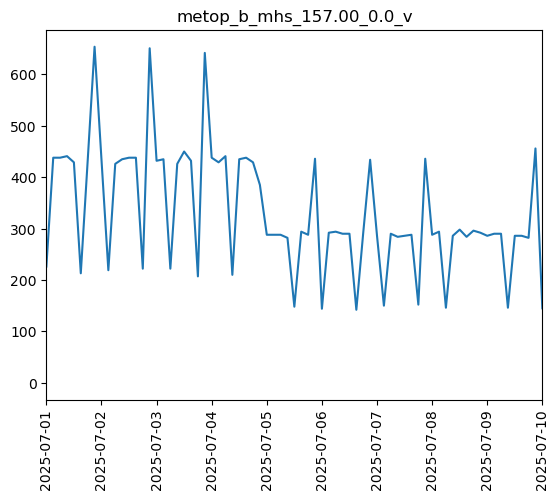

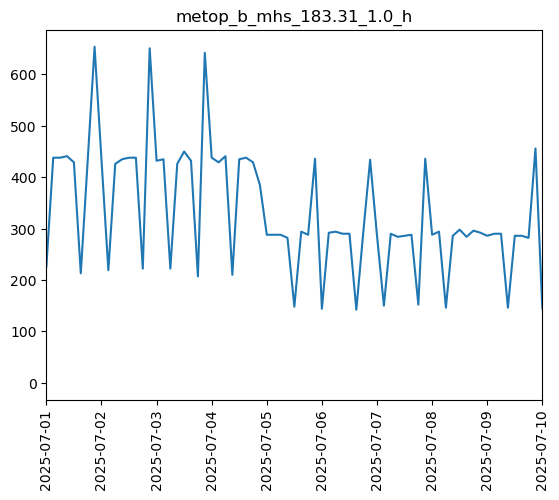

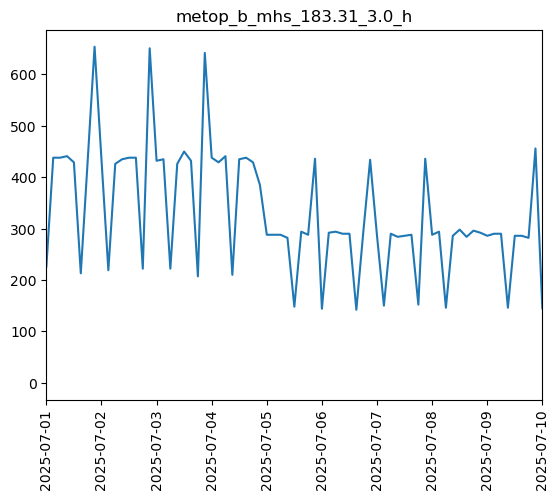

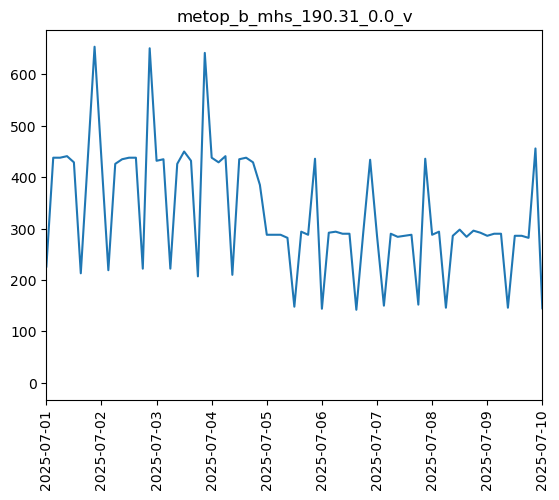

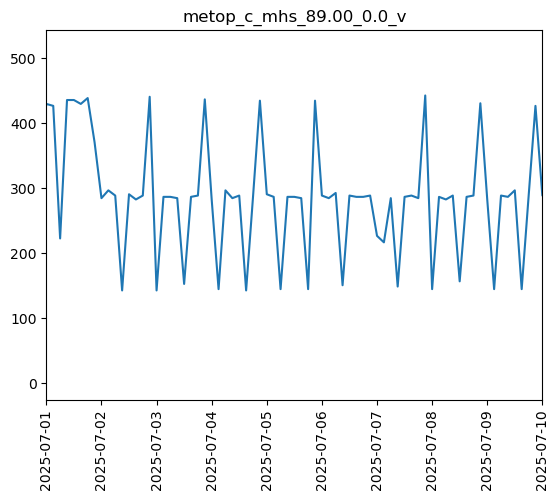

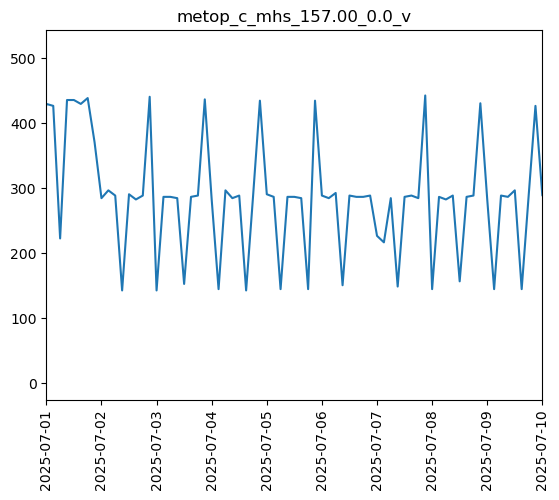

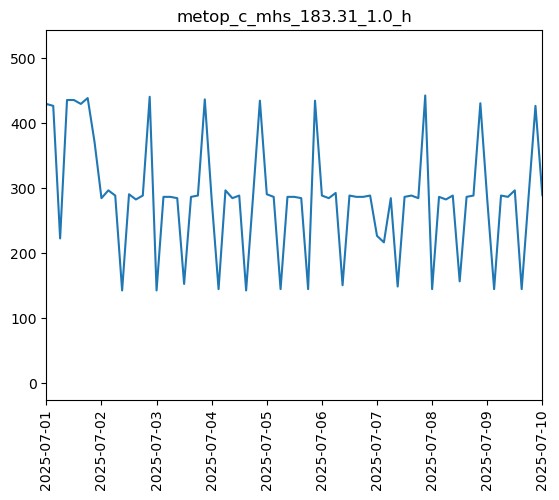

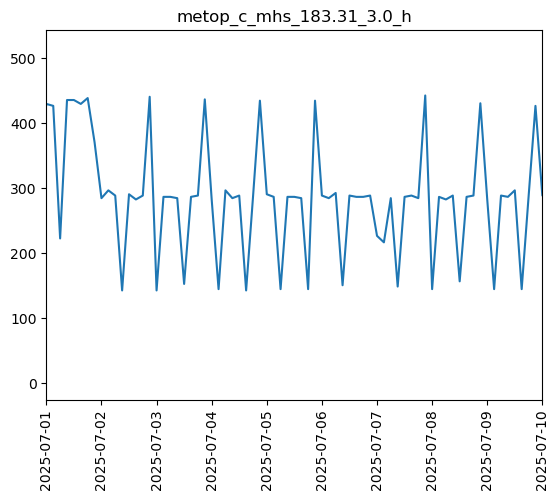

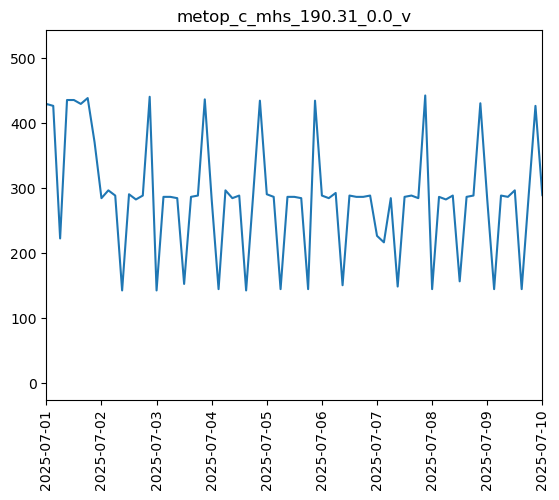

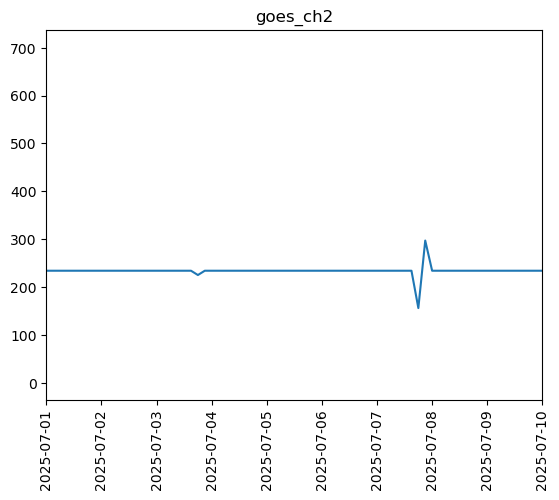

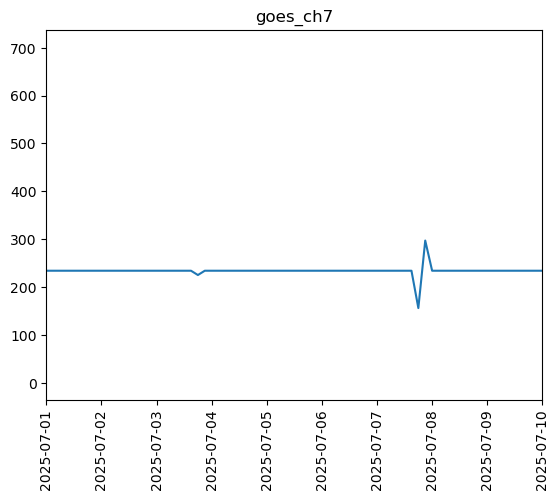

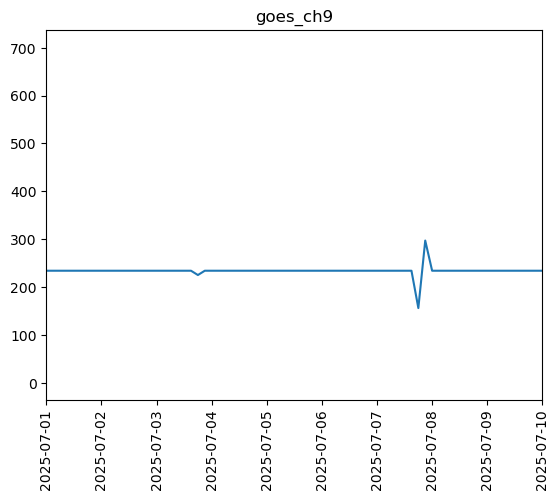

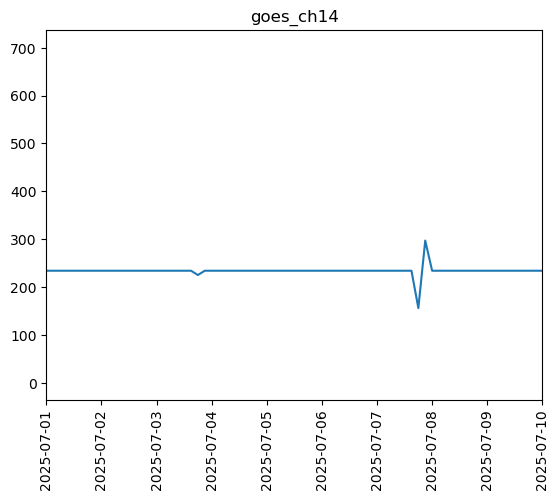

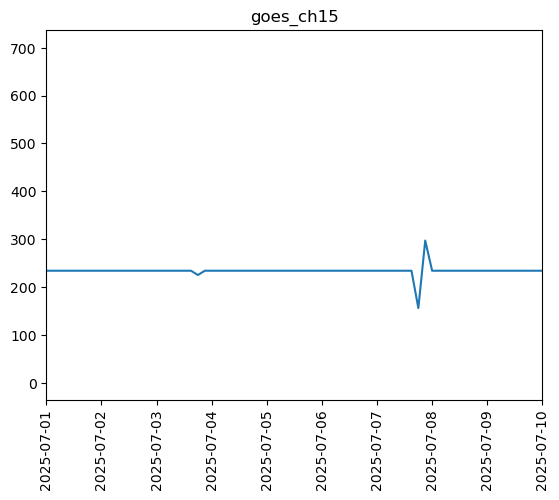

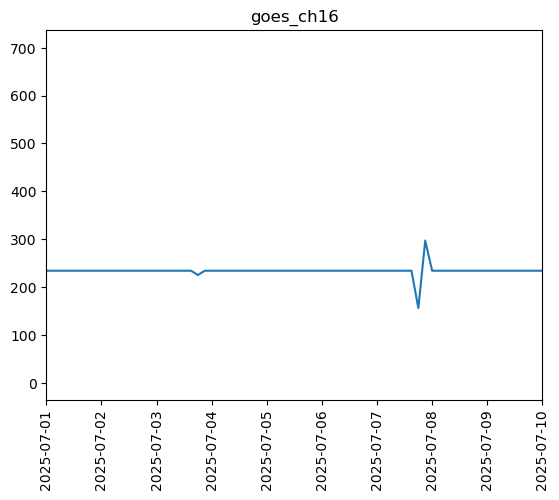

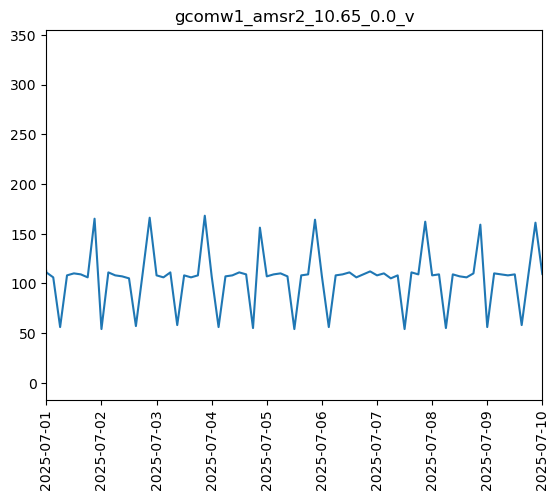

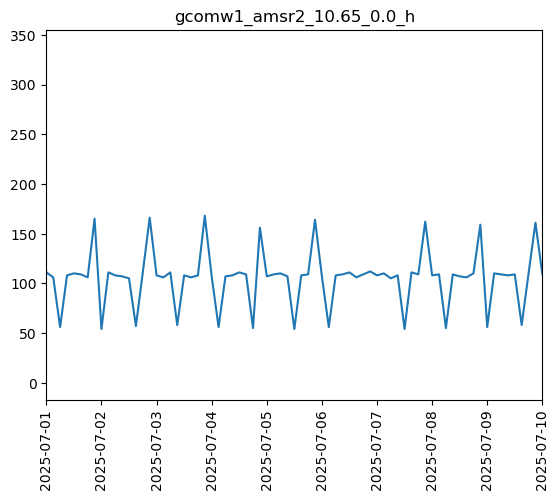

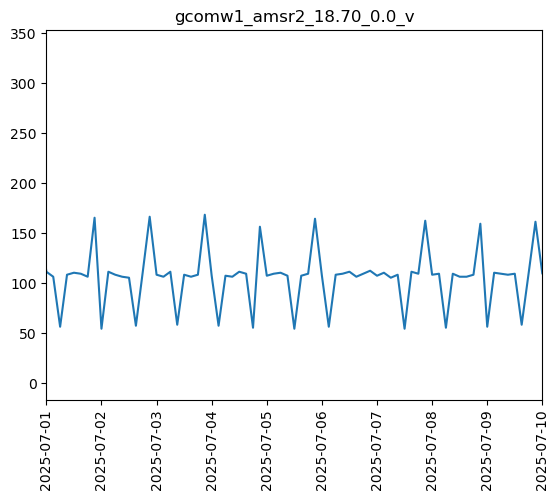

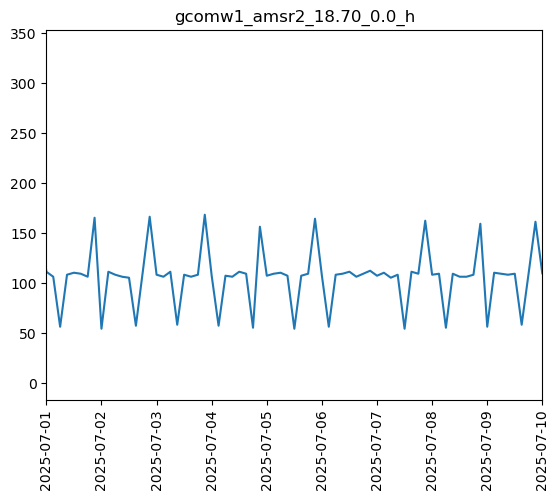

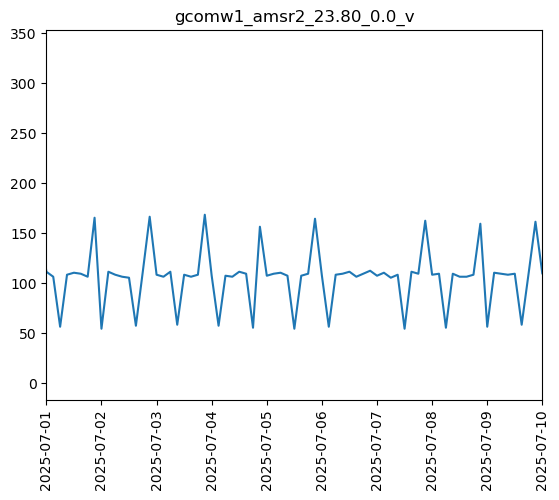

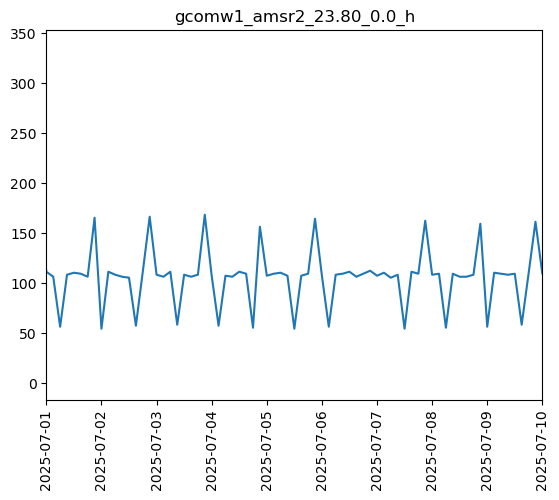

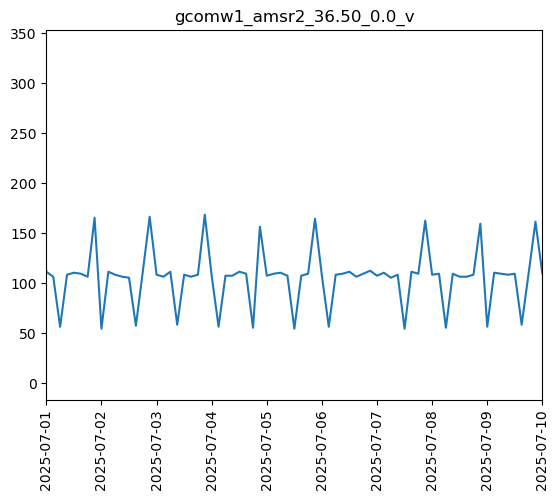

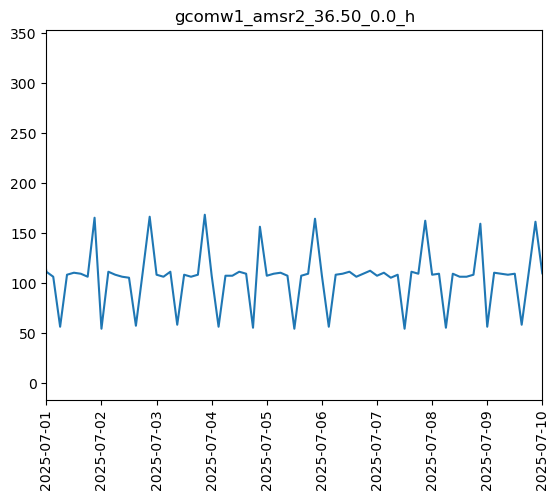

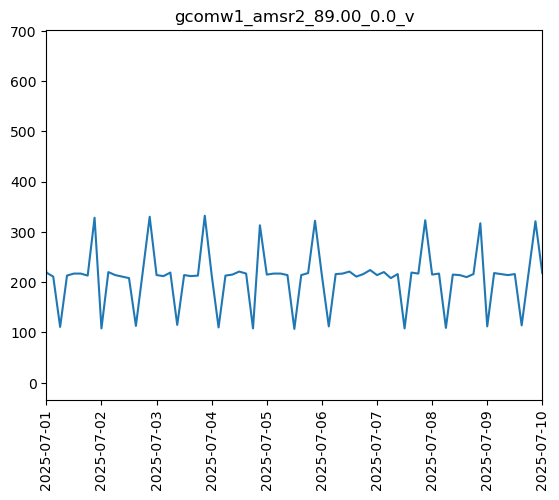

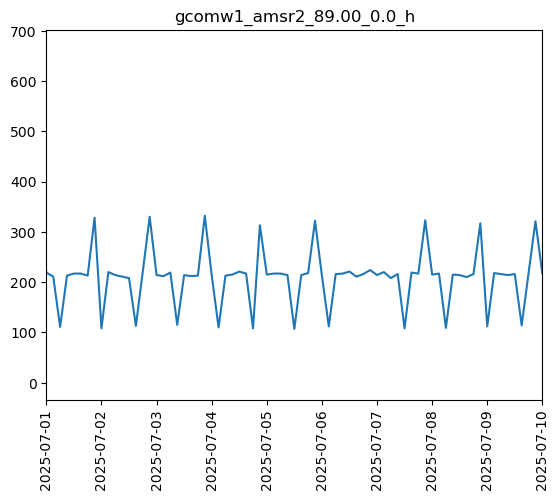

In [93]:
for obs_ind in range(obs.observations.size):
    plt.figure()
    plt.plot(obs.time, n_tiles[:, obs_ind])
    plt.title(obs.observations[obs_ind].data)
    plt.xlim(np.datetime64("2025-07-01"), np.datetime64("2025-07-10"))
    for lbl in plt.gca().xaxis.get_ticklabels():
        lbl.set_rotation(90)